In [1]:
import itertools

import numpy as np
import seaborn as sns
from matplotlib import collections, colormaps, legend_handler, patches
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy import linalg, optimize, stats

from nustattools import plotting as nuplt

In [2]:
rng = np.random.default_rng()

In [3]:
# Create the correlated covariance matrix
N = 3
cov = np.eye(N) * 0.2**2

u = np.array([2, -1, -2])
u = u[:, np.newaxis]
cov += u @ u.T

u = np.array([1, 1, 1]) * 0.5
u = u[:, np.newaxis]
cov += u @ u.T

In [4]:
err = np.sqrt(np.diag(cov))
cor = cov / err[:, np.newaxis] / err[np.newaxis, :]
covinv = np.linalg.inv(cov)
np.linalg.svd(cov, compute_uv=False), np.linalg.svd(cor, compute_uv=False)

(array([9.07019253, 0.75980747, 0.04      ]),
 array([2.71923588, 0.26462824, 0.01613588]))

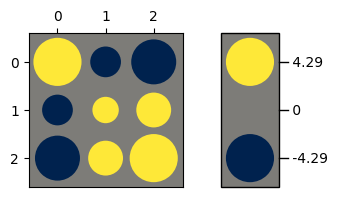

In [5]:
fig, ax = plt.subplots(figsize=(4, 2), dpi=100)
nuplt.hinton(cov, legend=True)
plt.savefig("plots/simple-cov.pdf", bbox_inches="tight")

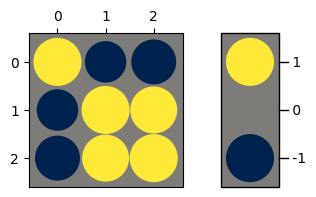

In [6]:
fig, ax = plt.subplots(figsize=(4, 2), dpi=100)
nuplt.hinton(cor, legend=True)
plt.savefig("plots/simple-cor.pdf", bbox_inches="tight")

In [7]:
# Generate some random data
x = np.arange(0, N)
y = rng.multivariate_normal([0] * N, cov)
y

array([-0.21554404,  0.80893392,  1.13231013])

In [8]:
# Define correct and wrong M-distances
def correct_dist(ymodel):
    dy = (ymodel - y)[:, np.newaxis]
    return (dy.T @ covinv @ dy).flat


def wrong_dist(ymodel):
    dy = ymodel - y
    return np.sum(dy**2 / err**2)

In [9]:
# Scale data to have target p-value
p = 0.32
chi2 = stats.chi2(df=N)
M = np.sqrt(correct_dist(np.array([0] * N)))
Mc = np.sqrt(chi2.isf(p))
y *= Mc / M
y

array([-0.41864744,  1.57117828,  2.19926628])

In [10]:
# A nice example
y = np.array([-2.18940775, 0.55018439, 0.99149541])

In [11]:
# Re-define correct and wrong M-distances
def correct_dist(ymodel):
    dy = (ymodel - y)[:, np.newaxis]
    return (dy.T @ covinv @ dy).flat


def wrong_dist(ymodel):
    dy = ymodel - y
    return np.sum(dy**2 / err**2)

In [12]:
# Do a correct fit
Nc = 1


def correct_fun(a):
    return np.sum([a[i] * x**i for i in range(Nc)], axis=0)


def correct_opt(a):
    return correct_dist(correct_fun(a))


correct_ret = optimize.minimize(correct_opt, x0=[0] * Nc)
chi_correct = correct_ret.fun
y_correct = correct_fun(correct_ret.x)

In [13]:
# Do a wrong fit
Nw = 2


def wrong_fun(a):
    return np.sum([a[i] * x**i for i in range(Nw)], axis=0)


def wrong_opt(a):
    return wrong_dist(wrong_fun(a))


wrong_ret = optimize.minimize(wrong_opt, x0=[0] * Nw)
chi_wrong = correct_dist(wrong_fun(wrong_ret.x))[0]
y_wrong = wrong_fun(wrong_ret.x)

2.1

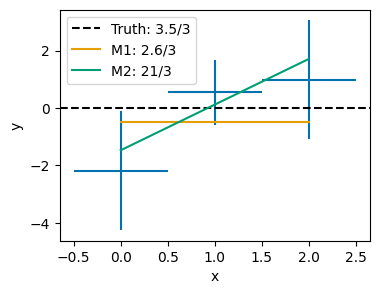

In [14]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=100)
chi_truth = correct_dist(correct_fun([0] * Nc))[0]
bars = plt.errorbar(x, y, yerr=np.sqrt(np.diag(cov)), xerr=0.5, fmt=" ")
plt.axhline(0, color="k", linestyle="--", label=f"Truth: {chi_truth:.2g}/{N}")
plt.plot(x, correct_fun(correct_ret.x), label=f"M1: {chi_correct:.2g}/{N}")
plt.plot(x, wrong_fun(wrong_ret.x), label=f"M2: {chi_wrong:.2g}/{N}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.savefig("plots/simple-diag.pdf", bbox_inches="tight")
bars.get_children()[0].zorder

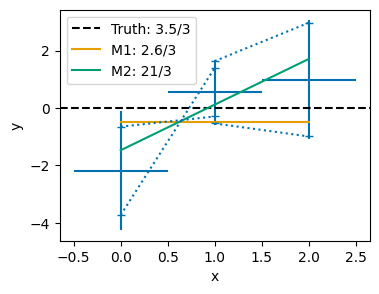

In [15]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=100)
bars = nuplt.corlines(x, y, cov, xerr=0.5, corlinestyle=":")
plt.axhline(0, color="k", linestyle="--", label=f"Truth: {chi_truth:.2g}/{N}")
plt.plot(x, correct_fun(correct_ret.x), label=f"M1: {chi_correct:.2g}/{N}")
plt.plot(x, wrong_fun(wrong_ret.x), label=f"M2: {chi_wrong:.2g}/{N}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.savefig("plots/simple-corlines.pdf", bbox_inches="tight")

{'K': array([[ 1.05081414,  0.09064445, -0.23571635],
        [ 0.09064445,  0.24406681,  0.25303318],
        [-0.23571635,  0.25303318,  0.47725504]]),
 'q': array([[-0.55462347, -0.78305954,  0.28144372],
        [ 0.57473292, -0.6050908 , -0.55095118],
        [ 0.60172657, -0.14381549,  0.78564765]]),
 'yconderr': array([0.76454513, 0.25197945, 0.33396498]),
 'd': array([2.71923588, 0.26462824, 0.01613588]),
 'n_comp': np.int64(1)}

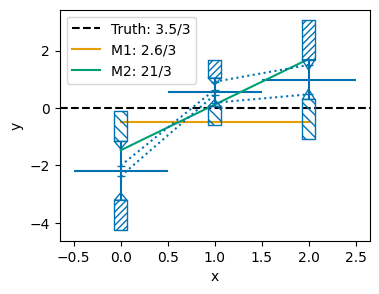

In [16]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=100)
ret = {}
nuplt.pcplot(x, y, cov, components=0.5, return_dict=ret, target_quantile=0.5, xerr=0.5)
plt.axhline(0, color="k", linestyle="--", label=f"Truth: {chi_truth:.2g}/{N}")
plt.plot(x, correct_fun(correct_ret.x), label=f"M1: {chi_correct:.2g}/{N}")
plt.plot(x, wrong_fun(wrong_ret.x), label=f"M2: {chi_wrong:.2g}/{N}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.savefig("plots/simple-pcplot.pdf", bbox_inches="tight")
ret

-2.071231517720798 2.071231517720798


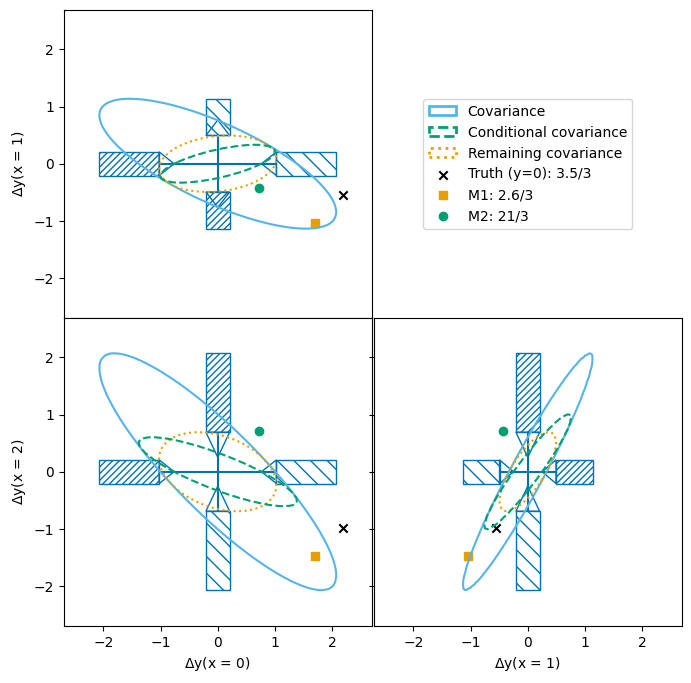

In [17]:
fig, axs = plt.subplots(
    N-1,
    N-1,
    sharex="col",
    sharey="row",
    figsize=(8, 8),
    dpi=100,
    gridspec_kw=dict(wspace=0, hspace=0),
)
ymin = np.min([-err, y_correct - y, y_wrong - y])
ymax = np.max([+err, y_correct - y, y_wrong - y])
print(ymin, ymax)
xx, yy = list(
    zip(*itertools.product(np.linspace(np.floor(ymin), np.ceil(ymax), 100), repeat=2))
)
xx = np.array(xx)
yy = np.array(yy)

for ix, iy in itertools.product(range(N-1), repeat=2):
    jx = ix
    jy = iy + 1
    
    # axs[iy][ix].set_adjustable("box")
    axs[iy][ix].set_aspect("equal", "box")
    axs[iy][ix].set_xlim(-1.3*ymax, 1.3*ymax)
    axs[iy][ix].set_ylim(-1.3*ymax, 1.3*ymax)
    axs[iy][ix].yaxis.set_major_locator(MaxNLocator(6, prune="both"))
    axs[iy][ix].xaxis.set_major_locator(MaxNLocator(6, prune="both"))

    if ix == 0:
        axs[iy, ix].set_ylabel(rf"$\Delta$y(x = {x[jy]:.4g})")
    if iy == N - 2:
        axs[iy, ix].set_xlabel(rf"$\Delta$y(x = {x[jx]:.4g})")

    if jx >= jy:
        axs[iy][ix].set_axis_off()
        continue

    xycov = cov[(jx, jy), :][:, (jx, jy)]
    xyK = ret["K"][(jx, jy), :][:, (jx, jy)]
    xycondinv = np.linalg.inv(cov)[(jx, jy), :][:, (jx, jy)]

    if jx == jy:
        xycov[0, 1] = xycov[1, 0] = 0
        xyK[0, 1] = xyK[1, 0] = 0
        xycondinv[0, 1] = xycondinv[1, 0] = 0

    xerr = np.sqrt(xycov[0, 0])
    yerr = np.sqrt(xycov[-1, -1])
    xKerr = np.sqrt(xyK[0, 0])
    yKerr = np.sqrt(xyK[-1, -1])
    xyu = ret["q"][:,0][(ix, iy),]
    xyw = ret["q"][:,-1][(ix, iy),]
    xconderr = ret["yconderr"][ix]
    yconderr = ret["yconderr"][iy]
    if jx != jy:
        axs[iy][ix].errorbar(0, 0, xerr=xKerr, yerr=yKerr, color="C0")
    else:
        axs[iy][ix].errorbar(0, 0, xerr=xKerr, color="C0")

    # Covariance ellipse
    xycovinv = np.linalg.inv(xycov)
    dx = xx - 0
    dy = yy - 0
    dd = np.array((dx, dy)).T
    zz = (dd[..., np.newaxis, :] @ xycovinv @ dd[..., :, np.newaxis])[:, 0, 0]
    if jx != jy:
        ell = axs[iy][ix].tricontour(xx, yy, zz, [1], colors="C3")

    # Remaining covariance ellipse
    xyKinv = np.linalg.inv(xyK)
    zz = (dd[..., np.newaxis, :] @ xyKinv @ dd[..., :, np.newaxis])[:, 0, 0]
    if jx != jy:
        pass
        axs[iy][ix].tricontour(xx, yy, zz, [1], colors="C1", linestyles=":")

    # Conditional covariance ellipse
    zz = (dd[..., np.newaxis, :] @ xycondinv @ dd[..., :, np.newaxis])[:, 0, 0]
    if jx != jy:
        axs[iy][ix].tricontour(xx, yy, zz, [1], colors="C2", linestyles="--")

    # 1st component boxes
    xw = yw = ymax / 5
    patch = patches.Rectangle(
        (0 - xerr, 0 - yw / 2),
        xerr - xKerr,
        yw,
        facecolor="none",
        edgecolor="C0",
    )
    if xyu[0] < 0:
        patch.set_hatch("/" * 5)
    else:
        patch.set_hatch("\\" * 2)
    axs[iy][ix].add_patch(patch)
    patch = patches.Rectangle(
        (0 + xerr, 0 - yw / 2),
        -(xerr - xKerr),
        yw,
        facecolor="none",
        edgecolor="C0",
    )
    if xyu[0] >= 0:
        patch.set_hatch("/" * 5)
    else:
        patch.set_hatch("\\" * 2)
    axs[iy][ix].add_patch(patch)

    if jx != jy:
        patch = patches.Rectangle(
            (0 - xw / 2, 0 - yerr),
            xw,
            yerr - yKerr,
            facecolor="none",
            edgecolor="C0",
        )
        if xyu[1] < 0:
            patch.set_hatch("/" * 5)
        else:
            patch.set_hatch("\\" * 2)
        axs[iy][ix].add_patch(patch)
        patch = patches.Rectangle(
            (0 - xw / 2, 0 + yerr),
            xw,
            -(yerr - yKerr),
            facecolor="none",
            edgecolor="C0",
        )
        if xyu[1] >= 0:
            patch.set_hatch("/" * 5)
        else:
            patch.set_hatch("\\" * 2)
        axs[iy][ix].add_patch(patch)
    
    # Last component triangles
    patch = patches.Polygon(
        [
            (0 - xKerr, 0 - yw / 2),
            (0 - xconderr, 0),
            (0 - xKerr, 0 + yw / 2),
        ],
        edgecolor="C0",
    )
    if True:  # xyw[0] < 0:
        patch.set_facecolor("none")
    else:
        patch.set_facecolor("C0")
        patch.set_alpha(0.8)
    axs[iy][ix].add_patch(patch)
    patch = patches.Polygon(
        [
            (0 + xKerr, 0 - yw / 2),
            (0 + xconderr, 0),
            (0 + xKerr, 0 + yw / 2),
        ],
        edgecolor="C0",
    )
    if True:  # xyw[0] >= 0:
        patch.set_facecolor("none")
    else:
        patch.set_facecolor("C0")
        patch.set_alpha(0.8)
    axs[iy][ix].add_patch(patch)

    if jx != jy:
        patch = patches.Polygon(
            [
                (0 - xw / 2, 0 - yKerr),
                (0, 0 - yconderr),
                (0 + xw / 2, 0 - yKerr),
            ],
            edgecolor="C0",
        )
        if True:  # xyw[1] < 0:
            patch.set_facecolor("none")
        else:
            patch.set_facecolor("C0")
            patch.set_alpha(0.8)
        axs[iy][ix].add_patch(patch)
        patch = patches.Polygon(
            [
                (0 - xw / 2, 0 + yKerr),
                (0, 0 + yconderr),
                (0 + xw / 2, 0 + yKerr),
            ],
            edgecolor="C0",
        )
        if True:  # xyw[1] >= 0:
            patch.set_facecolor("none")
        else:
            patch.set_facecolor("C0")
            patch.set_alpha(0.8)
        axs[iy][ix].add_patch(patch)
    
    # Truth
    if jx != jy:
        cors = axs[iy][ix].scatter(
            y_correct[jx] - y[jx], y_correct[jy] - y[jy], marker="s", color="C1"
        )
        wro = axs[iy][ix].scatter(
            y_wrong[jx] - y[jx], y_wrong[jy] - y[jy], marker="o", color="C2"
        )
        tru = axs[iy][ix].scatter(-y[jx], -y[jy], marker="x", color="k")
    else:
        axs[iy][ix].axvline(y_correct[jy] - y[jy], color="C1")
        axs[iy][ix].axvline(y_wrong[jy] - y[jy], color="C2")
        axs[iy][ix].axvline( - y[jy], color="k")

#leg_iy = np.argmin(err)

leg_artists = [
    patches.Ellipse(
        (0, 0), 1, 1, linewidth=2, edgecolor="C3", linestyle="-", facecolor="none"
    ),
    patches.Ellipse(
        (0, 0), 1, 1, linewidth=2, edgecolor="C2", linestyle="--", facecolor="none"
    ),
    patches.Ellipse(
        (0, 0), 1, 1, linewidth=2, edgecolor="C1", linestyle=":", facecolor="none"
    ),
    tru,
    cors,
    wro,
]
leg_labels = [
    "Covariance",
    "Conditional covariance",
    "Remaining covariance",
    f"Truth (y=0): {chi_truth:.2g}/{N}",
    f"M1: {chi_correct:.2g}/{N}",
    f"M2: {chi_wrong:.2g}/{N}",
]
axs[0][1].legend(leg_artists, leg_labels, loc="center")


plt.savefig("plots/simple-full.pdf", bbox_inches="tight")

3.690913557622881


/tmp/ipykernel_576353/2008351246.py:9: RuntimeWarning: Requested 5 principal components, but only 3 hatch styles are defined. Showing only 3 components.
  nuplt.pcplot(xe, ye, cove, xerr=0.5)


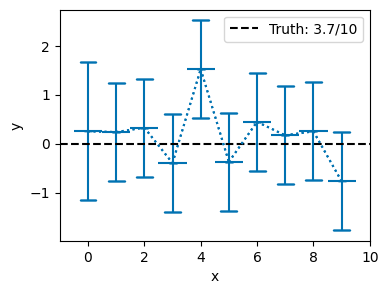

In [18]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=100)
Ne = 10
xe = np.arange(Ne)
cove = np.eye(Ne)
cove[0,0] = 2
ye = rng.multivariate_normal([0] * Ne, cove)
chi_truthe = (ye[np.newaxis, :] @ np.linalg.inv(cove) @ ye[:, np.newaxis]).flat[0]
print(chi_truthe)
nuplt.pcplot(xe, ye, cove, xerr=0.5)
plt.axhline(0, color="k", linestyle="--", label=f"Truth: {chi_truthe:.2g}/{Ne}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.savefig("plots/example-uncor.pdf", bbox_inches="tight")

7.459540921016811


/tmp/ipykernel_576353/104077574.py:9: RuntimeWarning: Requested 5 principal components, but only 3 hatch styles are defined. Showing only 3 components.
  nuplt.pcplot(xe, ye, cove, xerr=0.3, return_dict=ret)


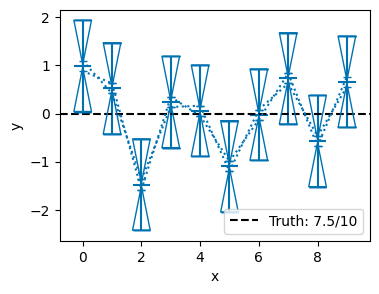

In [43]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=100)
cove = np.eye(Ne)
A = np.eye(Ne) - 0.99 * np.full((Ne, Ne), 1 / Ne)
cove = A @ cove @ A.T
ye = rng.multivariate_normal([0] * Ne, cove)
chi_truthe = (ye[np.newaxis, :] @ np.linalg.inv(cove) @ ye[:, np.newaxis]).flat[0]
print(chi_truthe)
ret = {}
nuplt.pcplot(xe, ye, cove, xerr=0.3, return_dict=ret)
plt.axhline(0, color="k", linestyle="--", label=f"Truth: {chi_truthe:.2g}/{Ne}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.savefig("plots/example-shape-only.pdf", bbox_inches="tight")

2.7839190446343176


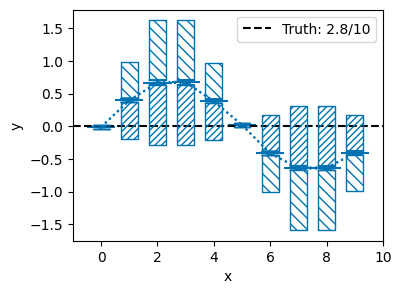

In [20]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=100)
cove = 0.001 * np.eye(Ne)
v1 = np.sin(2 * np.pi * (xe / Ne))
cove += v1[:, np.newaxis] @ v1[np.newaxis, :]
ye = rng.multivariate_normal([0] * Ne, cove)
chi_truthe = (ye[np.newaxis, :] @ np.linalg.inv(cove) @ ye[:, np.newaxis]).flat[0]
print(chi_truthe)
ret = {}
nuplt.pcplot(xe, ye, cove, components=1, xerr=0.5, return_dict=ret)
plt.axhline(0, color="k", linestyle="--", label=f"Truth: {chi_truthe:.2g}/{Ne}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.savefig("plots/example-single.pdf", bbox_inches="tight")

13.295417800366936


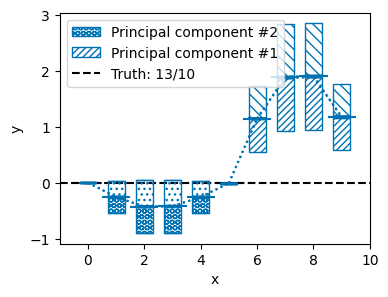

In [42]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=100)
cove = 0.0001 * np.eye(Ne)
v1 = np.sin(2 * np.pi * (xe / Ne))
v1[:5] = 0
v2 = np.sin(2 * np.pi * (xe / Ne)) * 0.5
v2[5:] = 0
cove += v1[:, np.newaxis] @ v1[np.newaxis, :]
cove += v2[:, np.newaxis] @ v2[np.newaxis, :]
ye = rng.multivariate_normal([0] * Ne, cove)
chi_truthe = (ye[np.newaxis, :] @ np.linalg.inv(cove) @ ye[:, np.newaxis]).flat[0]
print(chi_truthe)
nuplt.pcplot(xe, ye, cove, label_components=True, xerr=0.5)
plt.axhline(0, color="k", linestyle="--", label=f"Truth: {chi_truthe:.2g}/{Ne}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.savefig("plots/example-double.pdf", bbox_inches="tight")

4.175887708480918


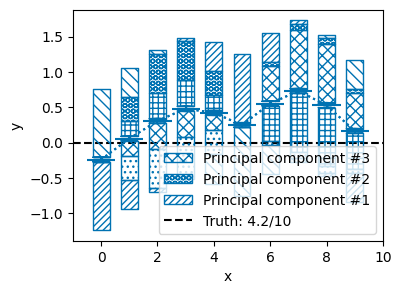

In [22]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=100)
cove = 0.001 * np.eye(Ne)
v1 = np.sin(2 * np.pi * (xe / Ne))
v1[:5] = 0
v2 = np.sin(2 * np.pi * (xe / Ne))
v2[5:] = 0
v3 = np.cos(2 * np.pi * (xe / Ne))

cove += v1[:, np.newaxis] @ v1[np.newaxis, :]
cove += v2[:, np.newaxis] @ v2[np.newaxis, :]
cove += v3[:, np.newaxis] @ v3[np.newaxis, :]
ye = rng.multivariate_normal([0] * Ne, cove)
chi_truthe = (ye[np.newaxis, :] @ np.linalg.inv(cove) @ ye[:, np.newaxis]).flat[0]
print(chi_truthe)
nuplt.pcplot(xe, ye, cove, components=3, xerr=0.5, label_components=True)
plt.axhline(0, color="k", linestyle="--", label=f"Truth: {chi_truthe:.2g}/{Ne}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.savefig("plots/example-triple.pdf", bbox_inches="tight")

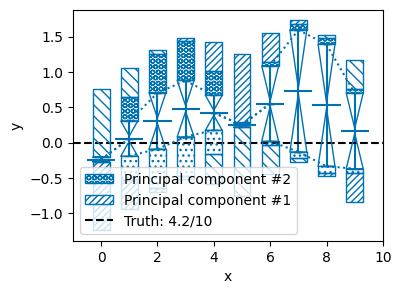

In [23]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=100)
nuplt.pcplot(xe, ye, cove, components=2, xerr=0.5, label_components=True)
plt.axhline(0, color="k", linestyle="--", label=f"Truth: {chi_truthe:.2g}/{Ne}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.savefig("plots/example-triple-two.pdf", bbox_inches="tight")

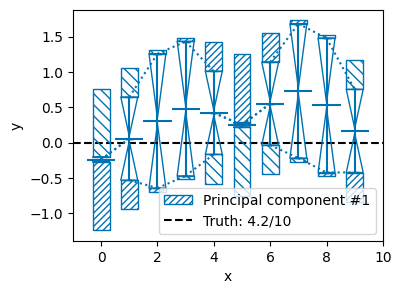

In [24]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=100)
nuplt.pcplot(xe, ye, cove, components=1, xerr=0.5, label_components=True)
plt.axhline(0, color="k", linestyle="--", label=f"Truth: {chi_truthe:.2g}/{Ne}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.savefig("plots/example-triple-one.pdf", bbox_inches="tight")